# Topological random walker

## parameters:

L : system size (square lattice with open boundary condition (OBC))

$D_r$ : rotational noise

$\omega \in [0,1]$ : chirality

note the extreme limits of $\omega$: 

$\omega=1$ : CW chiral move and CCW rotational noise

$\omega=0$ : CCW chiral move and CW rotational noise

Note that chiral move and rotational noise have opposite chiralities!

## outputs

P(X,Y)

$J_{D_r}$

$J_{\omega}$

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

import TRW

# 1. Square lattice without defects

In [52]:
### initialize


# parameters
L = 6 
D_r = 0.01   
omega = 1.0
total_steps = 20000000


# starting point
start_i = L // 2
start_j = L // 2


walker = TRW.ChiralWalker(i=start_i, j=start_j, D_r=D_r, omega=omega, L=L)

In [53]:
%%time

## RUN (~ 20 seconds)

for _ in range(total_steps):
    walker.step()

normalization = total_steps

# Save simulation results
np.savez(
    "walker_results.npz",
    P=walker.P/normalization,
    J_Dr=walker.J1/normalization,
    J_omega=walker.J2/normalization
)


CPU times: user 12.7 s, sys: 2.84 ms, total: 12.7 s
Wall time: 12.7 s


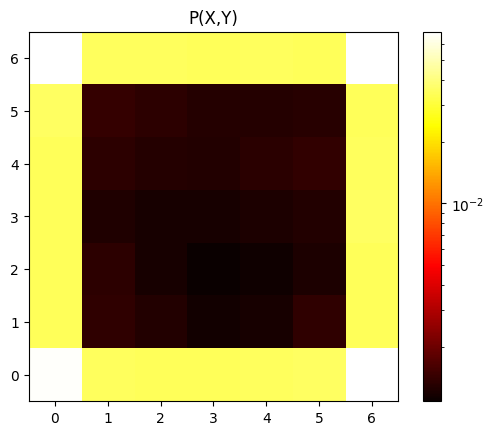

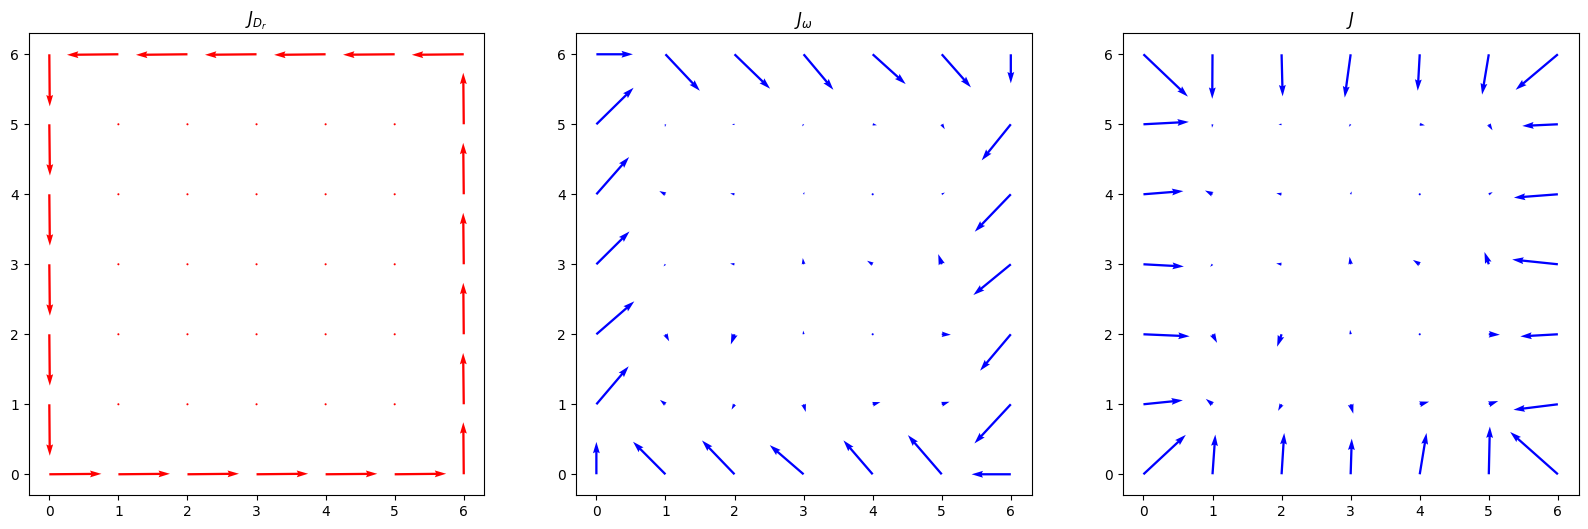

In [54]:
data = np.load("walker_results.npz")

P = data["P"]
J_Dr_sim = data["J_Dr"]
J_omega_sim = data["J_omega"]
J_total_sim = J_Dr_sim + J_omega_sim

# Plot P(X,Y)
plt.imshow(P.T, cmap='hot', origin='lower', norm=LogNorm(vmin=np.min(P), vmax=np.max(P)))
plt.title('P(X,Y)')
cbar = plt.colorbar()


# Plot currents
X, Y = np.meshgrid(np.arange(L+1), np.arange(L+1), indexing='ij')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.quiver(X, Y, J_Dr_sim[:, :, 0], J_Dr_sim[:, :, 1], color='red', width=0.005)

ax2.quiver(X, Y, J_omega_sim[:, :, 0], J_omega_sim[:, :, 1], color='blue',  width=0.005)

ax3.quiver(X, Y, J_total_sim[:,:,0], J_total_sim[:,:,1], color='blue',  width=0.005)

ax1.set_title(r'$J_{D_r}$')
ax2.set_title(r'$J_{\omega}$')
ax3.set_title(r'$J$')

plt.savefig('simulation.pdf')

## Steady States Analysis using transition matrix and compare with simulation

1.0


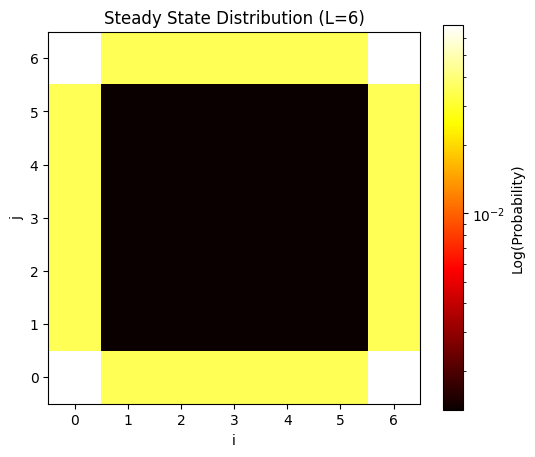

In [55]:
W_sparse = TRW.build_sparse_transition_matrix(L, omega, D_r)
P_ss, warning = TRW.solve_steady_state_sparse(W_sparse, L)

print(np.sum(P_ss))


TRW.visualize_steady_state(P_ss, L)


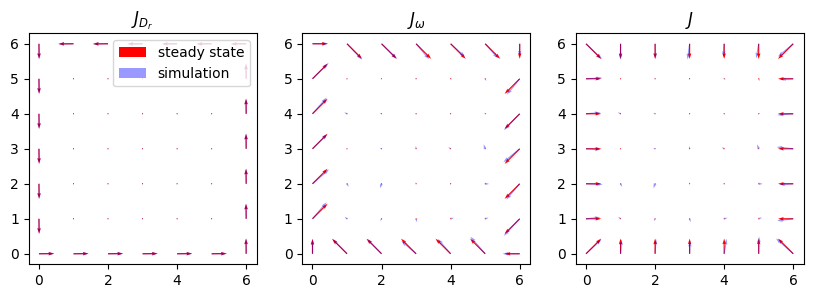

In [56]:
J_Dr, J_omega = TRW.calculate_J1_J2_with_boundaries (P_ss, W_sparse, L, D_r, omega)

J_total = J_Dr + J_omega

X, Y = np.meshgrid(np.arange(L+1), np.arange(L+1), indexing='ij')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))



scale= 0.005

### Plot steady state from transition matrix
ax1.quiver(X, Y, J_Dr[:,:,0], J_Dr[:,:,1], color='red', scale=scale, width=0.005, label='steady state')

ax2.quiver(X, Y, J_omega[:,:,0], J_omega[:,:,1], color='red', scale=scale, width=0.005)

ax3.quiver(X, Y, J_total[:,:,0], J_total[:,:,1], color='red', scale=scale, width=0.005)

### Plot results from simulation
ax1.quiver(X, Y, J_Dr_sim[:, :, 0], J_Dr_sim[:, :, 1], color='b', scale=scale, width=0.005, alpha=0.4, label='simulation')

ax2.quiver(X, Y, J_omega_sim[:, :, 0], J_omega_sim[:, :, 1], color='b', scale=scale, width=0.005, alpha=0.4)

ax3.quiver(X, Y, J_total_sim[:,:,0], J_total_sim[:,:,1], color='b', scale=scale, width=0.005, alpha=0.4)

ax1.set_title(r'$J_{D_r}$')
ax2.set_title(r'$J_{\omega}$')
ax3.set_title(r'$J$')

ax1.legend()

plt.savefig('compare_sim_and_ss.pdf')

# 2. Square lattice with defects

In [66]:
L = 10
omega = 1
D_r = 0.01

total_steps = 100000000

# starting point
start_i = 3
start_j = 3

defects = [(4, 5), (4, 6), (4,7), (5,5), (6, 5)]

walker = TRW.ChiralWalker(i=start_i, j=start_j, D_r=D_r, omega=omega, L=L, defects=defects)

In [67]:
%%time

### I ran and saved the data. Uncomment the following lines and run the cell again.


# run (~1 minute)
'''
for _ in range(total_steps):
    walker.step()

normalization = total_steps

# Save all arrays in one file
np.savez(
    "walker_results_defects.npz",
    P=walker.P/normalization,
    J_Dr=walker.J1/normalization,
    J_omega=walker.J2/normalization
)
'''

CPU times: user 1min 9s, sys: 67.1 ms, total: 1min 9s
Wall time: 1min 9s


In [70]:
def plot_walker_results(file_name, L, omega, D_r, defects=defects, scale=0.005):

    data = np.load(file_name)
    
    P  = data["P"]
    J_Dr_sim = data["J_Dr"]
    J_omega_sim = data["J_omega"]
    J_total_sim = J_Dr_sim + J_omega_sim
    

    # Calculate current from steady state P(X,Y)
    W_sparse = TRW.build_sparse_transition_matrix(L, omega, D_r, defects=defects)
    P_ss, warning = TRW.solve_steady_state_sparse(W_sparse, L, defects=defects)
    
    TRW.visualize_steady_state(P_ss, L, defects=defects)
    
    J1, J2 = TRW.calculate_J1_J2_with_boundaries (P_ss, W_sparse, L, D_r, omega, defects=defects)


    X, Y = np.meshgrid(np.arange(L+1), np.arange(L+1), indexing='ij')
    
    #########
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Plot P from simulation 
    im = axes[0].imshow(P.T, cmap='hot', origin='lower'),
                        #norm=LogNorm(vmin=np.min(P), vmax=np.max(P)))
    axes[0].set_title("P(X,Y) from simulation")
    #plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)


    # Plot currents from simulation
    axes[1].quiver(X, Y, J_Dr_sim[:, :, 0], J_Dr_sim[:, :, 1], color='red', scale=scale, width=0.005, label='simulation')

    axes[2].quiver(X, Y, J_omega_sim[:, :, 0], J_omega_sim[:, :, 1], color='red', scale=scale, width=0.005)
    
    axes[3].quiver(X, Y, J_total_sim[:,:,0], J_total_sim[:,:,1], color='red', scale=scale, width=0.005)

    
    # Plot steady state currents obtained from transition matrix
    axes[1].quiver(X, Y, J1[:,:,0], J1[:,:,1], color='blue', scale=scale, width=0.005, alpha=0.4, label='steady state')

    axes[2].quiver(X, Y, J2[:,:,0], J2[:,:,1], color='blue', scale=scale, width=0.005, alpha=0.4)
    
    axes[3].quiver(X, Y, J1[:,:,0]+J2[:,:,0], J1[:,:,1]+J2[:,:,1], color='blue', scale=scale, width=0.005, alpha=0.4)
    

    axes[1].set_title(r'$J_{D_r}$')
    axes[2].set_title(r'$J_{\omega}$')
    axes[3].set_title(r'$J$')

    axes[1].legend()
    
    for ax in axes:
        ax.set_aspect('equal')
     

    plt.savefig('sim_and_ss_defects.pdf')
    plt.tight_layout()
    plt.show()


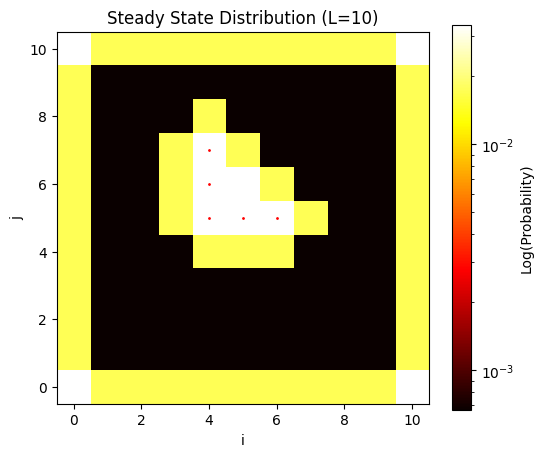

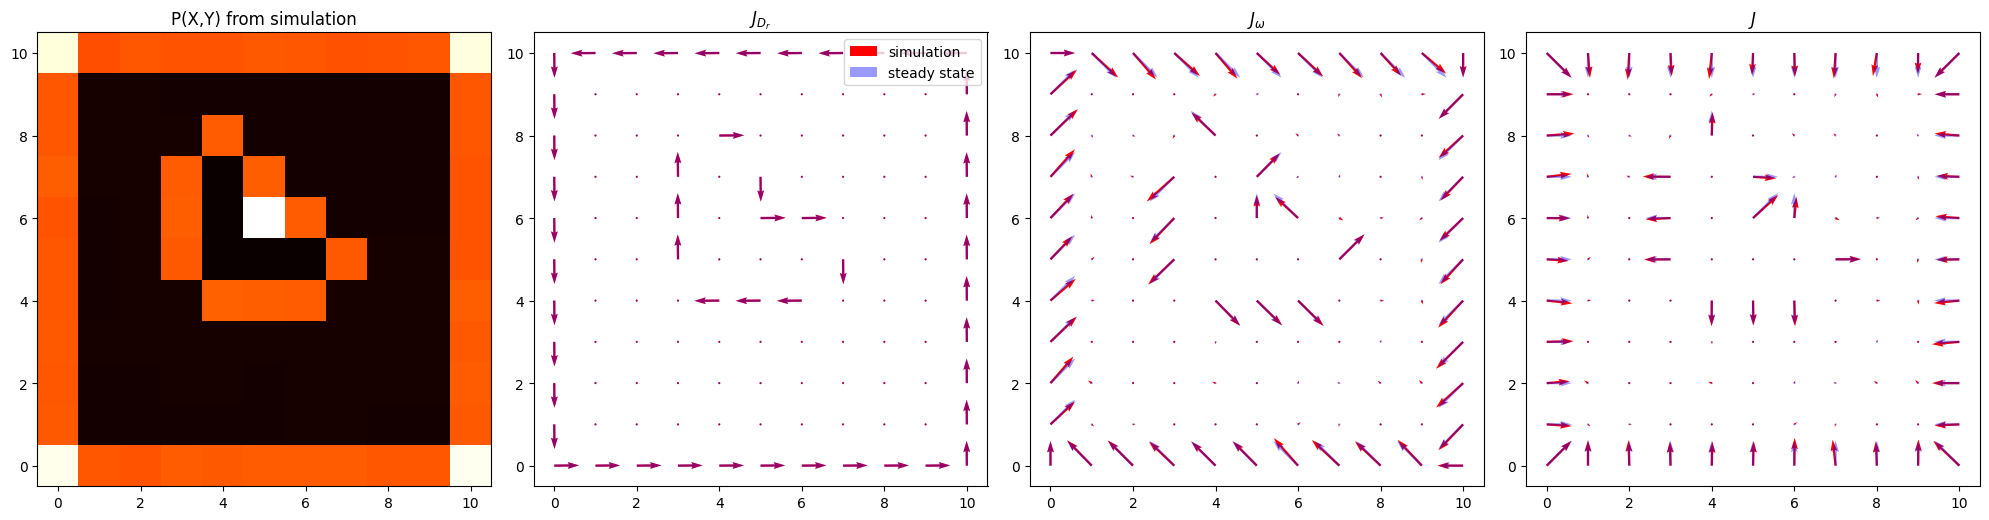

In [71]:
plot_walker_results("walker_results_defects.npz", L, omega, D_r, defects=defects, scale=0.003)



# Steady state P(X,Y,d), P(X,Y) and currents obtained from transition matrix

In [72]:
def visualize_steady_state(L, omega, D_r, defects, scale=0.005):


    # Calculate current from P steady state
    W_sparse = TRW.build_sparse_transition_matrix(L, omega, D_r, defects=defects)
    P_ss, warning = TRW.solve_steady_state_sparse(W_sparse, L, defects=defects)

    # Reshape P_ss to (L + 1, L + 1, 4)
    P_reshaped = P_ss.reshape((L + 1, L + 1, 4))
    
    #TRW.visualize_steady_state(P_ss, L, defects=defects)

    
    J1, J2 = TRW.calculate_J1_J2_with_boundaries (P_ss, W_sparse, L, D_r, omega, defects=defects)


    ###########################################################################
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    cmap = plt.cm.copper

    ###########################################################################
    states = ['→', '↓', '↑', '←'] 
    
    x=0.2
    arrow_positions = {
        '↑': (x, x),     # Upper left
        '←': (-x, x),    # Upper right
        '↓': (-x, -x),   # Lower left
        '→': (x, -x)     # Lower right
    }

    
    for i in range(L + 1):
        for j in range(L + 1):
            for state in states:
                state_idx = {'↑': 0, '→': 1, '↓': 2, '←': 3}[state]
                prob = P_reshaped[i, j, state_idx]
                
                if prob == 0:
                    continue
                
                # Get the x, y position for arrow
                dx, dy = arrow_positions[state]

                # Draw an arrow 
                angle = 90  # Default angle (facing '↑')
                if state == '→': angle = 0
                elif state == '↓': angle = 270
                elif state == '←': angle = 180

                color_val = np.clip((np.log10(prob) - np.log10(np.min(P_reshaped[P_reshaped > 0]))) /
                                (np.log10(np.max(P_reshaped)) - np.log10(np.min(P_reshaped[P_reshaped > 0]))), 0, 1)
            
                # Color for the circle and arrow
                arrow_color = plt.cm.copper(color_val)
        

                axes[0].arrow(i + dx, j + dy, 0.15 * np.cos(np.radians(angle)), 0.15 * np.sin(np.radians(angle)),
                      head_width=0.1, head_length=0.15, fc=arrow_color, ec=arrow_color, zorder=5)

    
    # Add colorbar for detailed plot
    sm = plt.cm.ScalarMappable(cmap=cmap, 
                              norm=LogNorm(vmin=np.min(P_reshaped[P_reshaped > 0]), vmax=np.max(P_reshaped)))

    cbar = plt.colorbar(sm, ax=axes[0], orientation='vertical', shrink=0.5)
    cbar.ax.set_title(r'$P(X,Y,\vec{d})$', pad=20)

    ###########################################################################
    
    # Summing up probabilities over all directions for each lattice point
    P_grid = np.zeros((L + 1, L + 1))
    
    for i in range(L + 1):
        for j in range(L + 1):
            P_grid[i, j] = np.sum(P_reshaped[i, j, :])

    
    im2 = axes[1].imshow(P_grid.T, origin='lower', cmap=cmap, interpolation=None,
                     norm=LogNorm(vmin=np.min(P_grid[P_grid > 0]), vmax=np.max(P_grid)))
    axes[1].set_xlabel(r'$X$')
    axes[1].set_ylabel(r'$Y$', rotation=0)
    cbar = plt.colorbar(im2, ax=axes[1], orientation='vertical', shrink=0.5)
    cbar.ax.set_title(r'$P(X,Y)$', pad=20)

    ###########################################################################

    cmap = plt.cm.copper_r
    
    X, Y = np.meshgrid(np.arange(L+1), np.arange(L+1), indexing='ij')
    
    J1_mag = np.sqrt(J1[:,:,0]**2 + J1[:,:,1]**2)
    J2_mag = np.sqrt(J2[:,:,0]**2 + J2[:,:,1]**2)
    Jtot_mag = np.sqrt((J1[:,:,0]+J2[:,:,0])**2 + (J1[:,:,1]+J2[:,:,1])**2)


    q1 = axes[2].quiver(X, Y, J1[:,:,0], J1[:,:,1], J1_mag, scale=scale, width=0.005, cmap=cmap
                       ,norm=LogNorm(vmin=np.min(J1_mag[J1_mag > 0]), vmax=np.max(J1_mag)) )
    cbar1 = plt.colorbar(q1, ax=axes[2], orientation='vertical', shrink=0.5)
    cbar1.ax.set_title(r"$|J_{D_r}|$", pad=20)
    
    q2 = axes[3].quiver(X, Y, J2[:,:,0], J2[:,:,1], J2_mag, scale=scale, width=0.005, cmap=cmap
                        ,norm=LogNorm(vmin=np.min(J2_mag[J2_mag > 0]), vmax=np.max(J2_mag)))
    cbar2 = plt.colorbar(q2, ax=axes[3], orientation='vertical', shrink=0.5)
    cbar2.ax.set_title(r"$|J_{\omega}|$", pad=20)
    
    qtot = axes[4].quiver(X, Y, J1[:,:,0]+J2[:,:,0], J1[:,:,1]+J2[:,:,1], Jtot_mag, scale=scale, width=0.005, cmap=cmap
                         ,norm=LogNorm(vmin=np.min(Jtot_mag[Jtot_mag > 0]), vmax=np.max(Jtot_mag)) )
    cbar_tot = plt.colorbar(qtot, ax=axes[4], orientation='vertical', shrink=0.5 
                            #,norm=LogNorm(vmin=np.min(Jtot_mag[Jtot_mag > 0]), vmax=np.max(Jtot_mag))
                            )
    cbar_tot.ax.set_title(r"$|J_{D_r} + J_{\omega}|$", pad=20)

    ###########################################################################

    for i in range(5):

        axes[i].set_aspect('equal')
        
        axes[i].set_xlim(-0.5, L + 0.5)
        axes[i].set_ylim(-0.5, L + 0.5)
    
        # Major ticks
        axes[i].set_xticks(np.arange(0, L+1, 1))
        axes[i].set_yticks(np.arange(0, L+1, 1))
        
        # Minor ticks
        axes[i].set_xticks(np.arange(0.5, L, 1), minor=True)
        axes[i].set_yticks(np.arange(0.5, L, 1), minor=True)
        axes[i].tick_params(axis='x', which='minor', length=0.2)  # length in points
        axes[i].tick_params(axis='y', which='minor', length=0.2)
        
        
        axes[i].grid(which='minor', color='gray', linestyle='-', linewidth=0.75)
        
        
        axes[i].grid(which='major', visible=False)

    # plot defects
    def_x = [d[0] for d in defects]
    def_y = [d[1] for d in defects]
    for ax in axes:
        ax.scatter(def_x, def_y, color='red', marker='x', s=50, linewidths=1, zorder=10)

    ###########################################################################
  
    plt.tight_layout()
    plt.savefig('steady_state.pdf')
    plt.show()


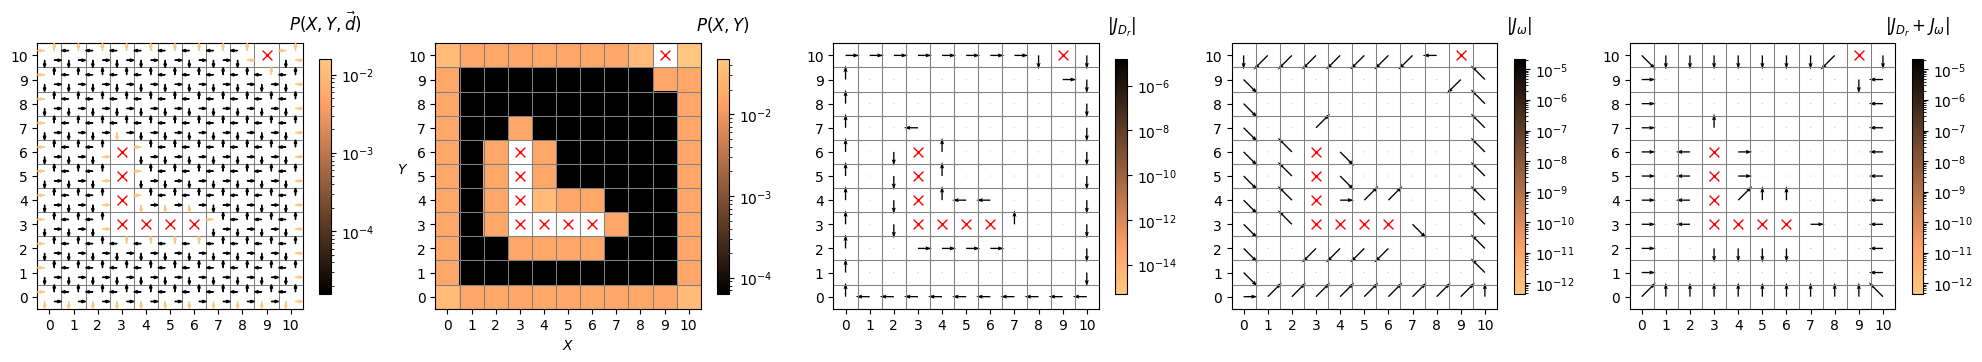

In [43]:
L=10
Dr = 0.001
omega=0.0

defects = [(9,10),
           (3, 3), (3, 4), (3,5), (3,6), (4,3), (5,3), (6,3)]

visualize_steady_state(L, omega, Dr, defects, scale=0.0003)

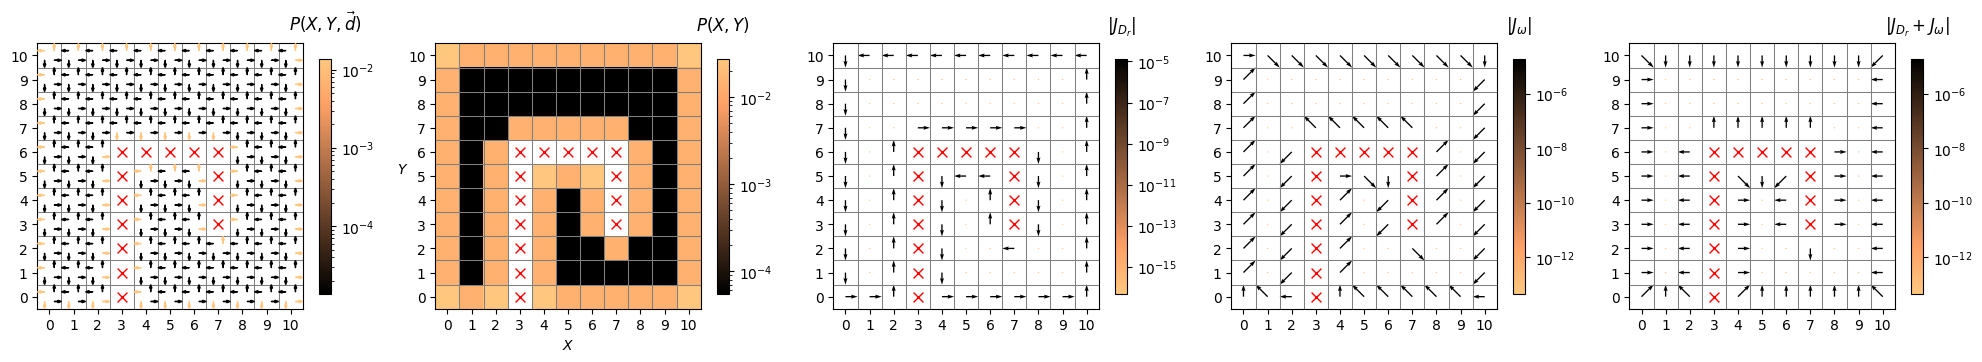

In [41]:
L=10
Dr = 0.001
omega=1

defects = [(3,0), (3,1), (3,2), (3,3), (3,4), (3,5), (3,6), 
           (4,6), (5,6), (6,6), (7,6),
           (7,5), (7,4), (7,3)]

visualize_steady_state(L, omega, Dr, defects, scale=0.0003)